In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

/opt/anaconda3/envs/timedrl/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create OOD datasets

In [39]:
def filter_and_save(split_name, base_path="../dataset/classification/PenDigits/"):
    # Load the original data
    load_path = os.path.join(base_path, f"{split_name}_orig.pt")
    data = torch.load(load_path)
    
    samples = data["samples"]
    labels = data["labels"]

    # Create mask: keep everything EXCEPT labels 1 and 4
    # mask = (labels != 1) & (labels != 4)

    # Create mask: Keep ONLY labels 1 and 4 (the OOD classes)
    mask = (labels == 1) | (labels == 4)

    filtered_dataset = {
        "samples": samples[mask],
        "labels": labels[mask]
    }

    # Save the filtered version
    save_path = os.path.join(base_path, f"{split_name}.pt")
    torch.save(filtered_dataset, save_path)
    
    print(f"Processed {split_name}: {len(samples)} -> {len(filtered_dataset['samples'])} samples.")



splits = ["train", "test", "val"]
for s in splits:
    filter_and_save(s)

Processed train: 7494 -> 1559 samples.
Processed test: 3498 -> 728 samples.


In [34]:
dataset = torch.load("../dataset/classification/PenDigits/test_orig.pt")

In [35]:
labels = dataset.get("labels").numpy()

unique, counts = np.unique(labels, return_counts=True)

In [36]:
print(dict(zip(unique, counts)))

{0.0: 363, 1.0: 364, 2.0: 364, 3.0: 336, 4.0: 364, 5.0: 335, 6.0: 336, 7.0: 364, 8.0: 336, 9.0: 336}


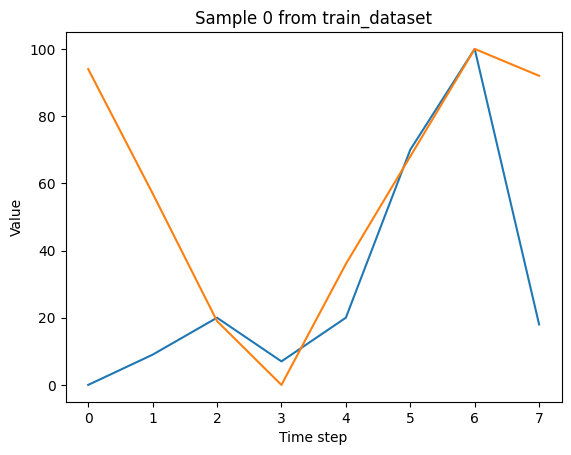

In [37]:
sample = dataset.get('samples')[2]

plt.figure()
plt.plot(sample)
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Sample 0 from train_dataset")
plt.show()